# BEE 4750 Homework 5: Mixed Integer and Stochastic Programming

**Name**: William Natcharian

**ID**: WRN25

> **Due Date**
>
> Thursday, 12/04/24, 9:00pm

## Overview

### Instructions

-   In Problem 1, you will use mixed integer programming to solve a
    waste load allocation problem.
-   In Problem 2, you will formulate a stochastic optimization problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [35]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("ImageView")
Pkg.add("FileIO")
Pkg.add("JpegTurbo")

  Activating project at `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5`
   Resolving package versions...
  No Changes to `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Project.toml`
  No Changes to `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Project.toml`
  No Changes to `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Manifest.toml`
   Resolving package versions...
   Installed JpegTurbo ─ v0.1.6
    Updating `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Project.toml`
  [b835a17e] + JpegTurbo v0.1.6
    Updating `~/Desktop/4750 Cloned Repositories/hw5-wrn25_hw5/Manifest.toml`
  [b835a17e] + JpegTurbo v0.1.6
Precompiling project...
   1865.1 ms  ✓ JpegTurbo
  1 dependency successfully precompiled in 2 seconds. 287 already precompiled.


In [36]:
using JuMP
using HiGHS
using DataFrames
using GraphRecipes
using Plots
using Measures
using MarkdownTables
using ImageView
using FileIO
using JpegTurbo

## Problems (Total: 30 Points)

### Problem 1 (24 points)

Three cities are developing a coordinated municipal solid waste (MSW)
disposal plan. Three disposal alternatives are being considered: a
landfill (LF), a materials recycling facility (MRF), and a
waste-to-energy facility (WTE). The capacities of these facilities and
the fees for operation and disposal are provided below.

-   **LF**: Capacity 200 Mg, fixed cost \$2000/day, tipping cost
    \$50/Mg;
-   **MRF**: Capacity 350 Mg, fixed cost \$1500/day, tipping cost
    \$7/Mg, recycling cost \$40/Mg recycled;
-   **WTE**: Capacity 210 Mg, fixed cost \$2500/day, tipping cost
    \$60/Mg;

The MRF recycling rate is 40%, and the ash fraction of non-recycled
waste is 16% and of recycled waste is 14%. Transportation costs are
\$1.5/Mg-km, and the relative distances between the cities and
facilities are provided in the table below.

| **City/Facility** | **Landfill (km)** | **MRF (km)** | **WTE (km)** |
|:-----------------:|:-----------------:|:------------:|:------------:|
|         1         |         5         |      30      |      15      |
|         2         |        15         |      25      |      10      |
|         3         |        13         |      45      |      20      |
|        LF         |        \-         |      32      |      18      |
|        MRF        |        32         |      \-      |      15      |
|        WTE        |        18         |      15      |      \-      |

The fixed costs associated with the disposal options are incurred only
if the particular disposal option is implemented. The three cities
produce 100, 90, and 120 Mg/day of solid waste, respectively, with the
composition provided in the table below.

| **Component** | **% of total mass** | **Combustion ash** (%) | **MRF Recycling rate** (%) |
|:---------------------:|:--------------:|:---------------:|:---------------:|
| Food Wastes | 15 | 8 | 0 |
| Paper & Cardboard | 40 | 7 | 55 |
| Plastics | 5 | 5 | 15 |
| Textiles | 3 | 10 | 10 |
| Rubber, Leather | 2 | 15 | 0 |
| Wood | 5 | 2 | 30 |
| Yard Wastes | 18 | 2 | 40 |
| Glass | 4 | 100 | 60 |
| Ferrous | 2 | 100 | 75 |
| Aluminum | 2 | 100 | 80 |
| Other Metal | 1 | 100 | 50 |
| Miscellaneous | 3 | 70 | 0 |

The information in the above table will help you determine the overall
recycling and ash fractions. Note that the recycling residuals, which
may be sent to either landfill or the WTE, have different ash content
than the ash content of the original MSW. You will need to determine
these fractions to construct your mass balance constraints.

**Reminder**: Use `round(x; digits=n)` to report values to the
appropriate precision!

#### Problem 1.1

Based on the information above, calculate the overall recycling and ash
fractions for the waste produced by each city.

--> Overall the recycling fraction of incoming MSW is 37.75%. The overall combustion ash fraction of the original MSW is 16.41%. And the Residual non-recycled fractions is 62.25%. Leaving the ash fraction of the residual stream at 13.861%. Thus the totals for each citya re as follows:

**City 1:** (100Mg/day)

- Recycled = 37.75 Mg/day

- Residual = 62.25 Mg/day

- Ash if all MSW burned = 16.41 Mg/day

- Ash from residuals = 8.629 Mg/day

**City 2:** (90 Mg/day)

- Recycled = 33.975 Mg/day

- Residual = 56.025 Mg/day

- Ash if all MSW burned = 14.769 Mg/day

- Ash from residuals = 7.766 Mg/day

**City 3:** (120 Mg/day)

- Recycled = 45.30 Mg/day

- Residual = 74.70 Mg/day

- Ash if all MSW burned = 19.692 Mg/day

- Ash from residuals = 10.354 Mg/day

#### Problem 1.2

What are the decision variables for your optimization problem? Provide
notation and variable meaning.

**Decision Variables**

--> Amount of waste [in Mg/day] allocated to each of the three waste disposal facilities from the threee separate cities (9 total variables):

- $LF_1, LF_2, LF_3$ (i.e. amount of waste allocated to the landfill from city 1,2,3)
- $MRF_1, MRF_2, MRF_3$
- $WTE_1, WTE_2, WTE_3$

--> MRF residual-routing variables: (satisfying the residual mass balance)

- $yLF_1, yLF_2, yLF_3$

- $yWTE_1, yWTE_2, yWTE_3$

-->  Binary variables for fixed cost:

- $zLF \in {0,1}$

- $zMRF \in {0,1}$

- $zWTE \in {0,1}$

--> Extra variables for Ash and Recycling:

- $S_{ash}$

- $Total_{recycled}$

#### Problem 1.3

Formulate the objective function. Make sure to include any needed
derivations or justifications for your equation(s).

**Objective Function**

$Min( 2000*zLF + 1500*zMRF + 2500*zWTE$

$+LF_1*(50 + 1.5*5) + LF_2*(50 + 1.5*15) + LF_3*(50 + 1.5*13) $
 
$ +MRF_1*(7 + 1.5*30 + 40*0.3775) + MRF_2*(7 + 1.5*25 + 40*0.3775) + MRF_3*(7 + 1.5*45 + 40*0.3775) $

$+WTE_1*(60 + 1.5*15 + 0.1641*(50 + 1.5*18)) + WTE_2*(60 + 1.5*10 + 0.1641*(50 + 1.5*18)) + WTE_3*(60 + 1.5*20 + 0.1641*(50 + 1.5*18)) $

$+yLF_1*(50 + 1.5*32) + yLF_2*(50 + 1.5*32) + yLF_3*(50 + 1.5*32) $
 
$ +yWTE_1*(60 + 1.5*15 + 0.13861*(50 + 1.5*18)) + yWTE_2*(60 + 1.5*15 + 0.13861*(50 + 1.5*18)) + yWTE_3*(60 + 1.5*15 + 0.13861*(50 + 1.5*18)))$

 --> This equation comes from the overall goal to minimize the cost of transporting and processing the waste from each city. The distances between each location are different and may make the optimization process prefer a certain facility even if by itself it is less economically efficient to operate. Also we have to incorporate the cost of recycling into this optimization equation at every point.

#### Problem 1.4

Derive all relevant constraints. Make sure to include any needed
justifications or derivations.

**Constraints**

--> City mass balances (all waste from each city is sent somewhere):

- LF_1 + MRF_1  + WTE_1  == 100

- LF_2 + MRF_2  + WTE_2  ==  90

- LF_3 + MRF_3  + WTE_3  == 120

--> MRF residual split (residual fraction r = 0.6225):

- yLF_1  + yWTE_1  == 0.6225 * MRF_1

- yLF_2  + yWTE_2  == 0.6225 * MRF_2

- yLF_3  + yWTE_3  == 0.6225 * MRF_3

--> WTE ash mass (definition):

- S_ash == 0.1641*(WTE_1 + WTE_2 + WTE_3) + 0.13861*(yWTE_1 + yWTE_2 + yWTE_3)

--> Facility load capacity constraints (linked to z) as the Landfill receives direct deliveries + residuals + WTE ash:

- (LF_1 + LF_2 + LF_3) + (yLF_1 + yLF_2 + yLF_3) + S_ash <= 200 * z_LF

--> MRF input (sum of city flows to MRF):

- (MRF_1 + MRF_2 + MRF_3) <= 350 * z_MRF

--> WTE input (direct + residuals sent to WTE):

- (WTE_1 + WTE_2 + WTE_3) + (yWTE_1 + yWTE_2 + yWTE_3) <= 210 * z_WTE

--> Per-city strengthening (prevents sending to closed facilities):

- LF_1  <= 100 * z_LF

- LF_2  <=  90 * z_LF

- LF_3  <= 120 * z_LF

- MRF_1 <= 100 * z_MRF

- MRF_2 <=  90 * z_MRF

- MRF_3 <= 120 * z_MRF

- WTE_1 <= 100 * z_WTE

- WTE_2 <=  90 * z_WTE

- WTE_3 <= 120 * z_WTE

--> Residual upper-bounds (numerical strengthening; redundant with equality but helpful):

- yLF_1  <= 0.6225 * MRF_1

- yWTE_1 <= 0.6225 * MRF_1

- yLF_2  <= 0.6225 * MRF_2

- yWTE_2 <= 0.6225 * MRF_2

- yLF_3  <= 0.6225 * MRF_3

- yWTE_3 <= 0.6225 * MRF_3

--> Recycling accounting (for reporting/cost term):

- Total_Recycled == 0.3775 * (MRF_1 + MRF_2 + MRF_3)

--> Nonnegativity and integrality since all flow variables >= 0; z variables are binary {0,1}

- LF_1, LF_2, LF_3 >= 0

- MRF_1, MRF_2, MRF_3 >= 0

- WTE_1, WTE_2, WTE_3 >= 0

- yLF_1, yLF_2, yLF_3 >= 0

- yWTE_1, yWTE_2, yWTE_3 >= 0

- z_LF in {0,1}

- z_MRF in {0,1}

- z_WTE in {0,1}

#### Problem 1.5

Find the optimal solution (using `JuMP` to solve the problem). Report
the optimal objective value.

In [37]:
MSW_model = Model(HiGHS.Optimizer) # initialize model object
@variable(MSW_model, S[1:20] >= 0) # non-negativity constraints
@variable(MSW_model, B[16:18], Bin)
@variable(MSW_model, G[19:20]>= 0)

@objective(MSW_model, Min, 2000B[16] + 1500B[17] + 2500B[18] + 57.5S[1] + 72.5S[2] + 69.5S[3] + 67.1S[4] + 59.6S[5] +
89.6S[6] + 93.17297S[7] + 62.6357S[8] + 102.6357S[9] + 98S[10] + 98S[11] + 98S[12] + 93.17297S[13] + 93.17297S[14] + 93.17297S[15])

@constraint(MSW_model, city1_total, S[1] + S[4] + S[7] == 100)
@constraint(MSW_model, city2_total, S[2] + S[5] + S[8] == 90)
@constraint(MSW_model, city3_total, S[3] + S[6] + S[9] == 120)

@constraint(MSW_model, res_split1, -S[10] + S[13] == 0.6225S[5])
@constraint(MSW_model, res_split2, -S[11] + S[14] == 0.6225S[6])
@constraint(MSW_model, res_split3, -S[12] + S[15] == 0.6225S[7])

@constraint(MSW_model, ash_mass, 0.1641(S[7] + S[8] + S[9]) + 0.13861(S[13] + S[14] + S[15]) == G[19])
@constraint(MSW_model, load_capacity, -S[1] - S[2] - S[3] + S[10] + S[11] + S[12] + G[19] <= 200B[16])

@constraint(MSW_model, MRF_input, (S[4] + S[5] + S[6]) <= 350B[17])
@constraint(MSW_model, WTE_input, -(S[7] + S[8] + S[9]) + (S[13] + S[14] + S[15]) <= 210B[18])

# Prevent sending to closed facilities
#@constraint(MSW_model, str_LF1, S[1] <= 100B[16])
#@constraint(MSW_model, str_LF2, S[2] <= 90B[16])
#@constraint(MSW_model, str_LF3, S[3] <= 120B[16])
#@constraint(MSW_model, str_MRF1, S[4] <= 100B[17])
#@constraint(MSW_model, str_MRF2, S[5] <= 90B[17])
#@constraint(MSW_model, str_MRF3, S[6] <= 120B[17])
#@constraint(MSW_model, str_WTE1, S[7] <= 100B[18])
#@constraint(MSW_model, str_WTE2, S[8] <= 90B[18])
#@constraint(MSW_model, str_WTE3, S[9] <= 120B[18])

@constraint(MSW_model, res_yLF1, S[10] <= 0.6225S[4])
@constraint(MSW_model, res_WTE1, S[13] <= 0.6225S[4])
@constraint(MSW_model, res_yLF2, S[11] <= 0.6225S[5])
@constraint(MSW_model, res_WTE2, S[14] <= 0.6225S[5])
@constraint(MSW_model, res_yLF3, S[12] <= 0.6225S[6])
@constraint(MSW_model, res_WTE3, S[15] <= 0.6225S[6])

@constraint(MSW_model, rec_acc, 0.3775(S[4] + S[5] + S[6]) == G[20])



print(MSW_model) # this outputs a nicely formatted summary of the model so you can check your specification

optimize!(MSW_model)

@show value.(S);
@show objective_value(MSW_model);
#total = sum(value.(S))
#variable = 0
#print("Total something: $variable")

Min 2000 B[16] + 1500 B[17] + 2500 B[18] + 57.5 S[1] + 72.5 S[2] + 69.5 S[3] + 67.1 S[4] + 59.6 S[5] + 89.6 S[6] + 93.17297 S[7] + 62.6357 S[8] + 102.6357 S[9] + 98 S[10] + 98 S[11] + 98 S[12] + 93.17297 S[13] + 93.17297 S[14] + 93.17297 S[15]
Subject to
 city1_total : S[1] + S[4] + S[7] = 100
 city2_total : S[2] + S[5] + S[8] = 90
 city3_total : S[3] + S[6] + S[9] = 120
 res_split1 : -0.6225 S[5] - S[10] + S[13] = 0
 res_split2 : -0.6225 S[6] - S[11] + S[14] = 0
 res_split3 : -0.6225 S[7] - S[12] + S[15] = 0
 ash_mass : 0.1641 S[7] + 0.1641 S[8] + 0.1641 S[9] + 0.13861 S[13] + 0.13861 S[14] + 0.13861 S[15] - G[19] = 0
 rec_acc : 0.3775 S[4] + 0.3775 S[5] + 0.3775 S[6] - G[20] = 0
 load_capacity : -S[1] - S[2] - S[3] + S[10] + S[11] + S[12] - 200 B[16] + G[19] ≤ 0
 MRF_input : S[4] + S[5] + S[6] - 350 B[17] ≤ 0
 WTE_input : -S[7] - S[8] - S[9] + S[13] + S[14] + S[15] - 210 B[18] ≤ 0
 res_yLF1 : -0.6225 S[4] + S[10] ≤ 0
 res_WTE1 : -0.6225 S[4] + S[13] ≤ 0
 res_yLF2 : -0.6225 S[5] + S[1

19727.213

--> Code Explanation: I used the JuMP model to solve this very complicated collection of equations. I compiled all the constraints into simple like-groups to make it easier to understand. And I used methods I previously used in lab 3 and hw 4 to compelte the algorithms above.

#### Problem 1.6

Draw a diagram showing the flows of waste between the cities and the
facilities. Which facilities (if any) will not be used? Does this
solution make sense?

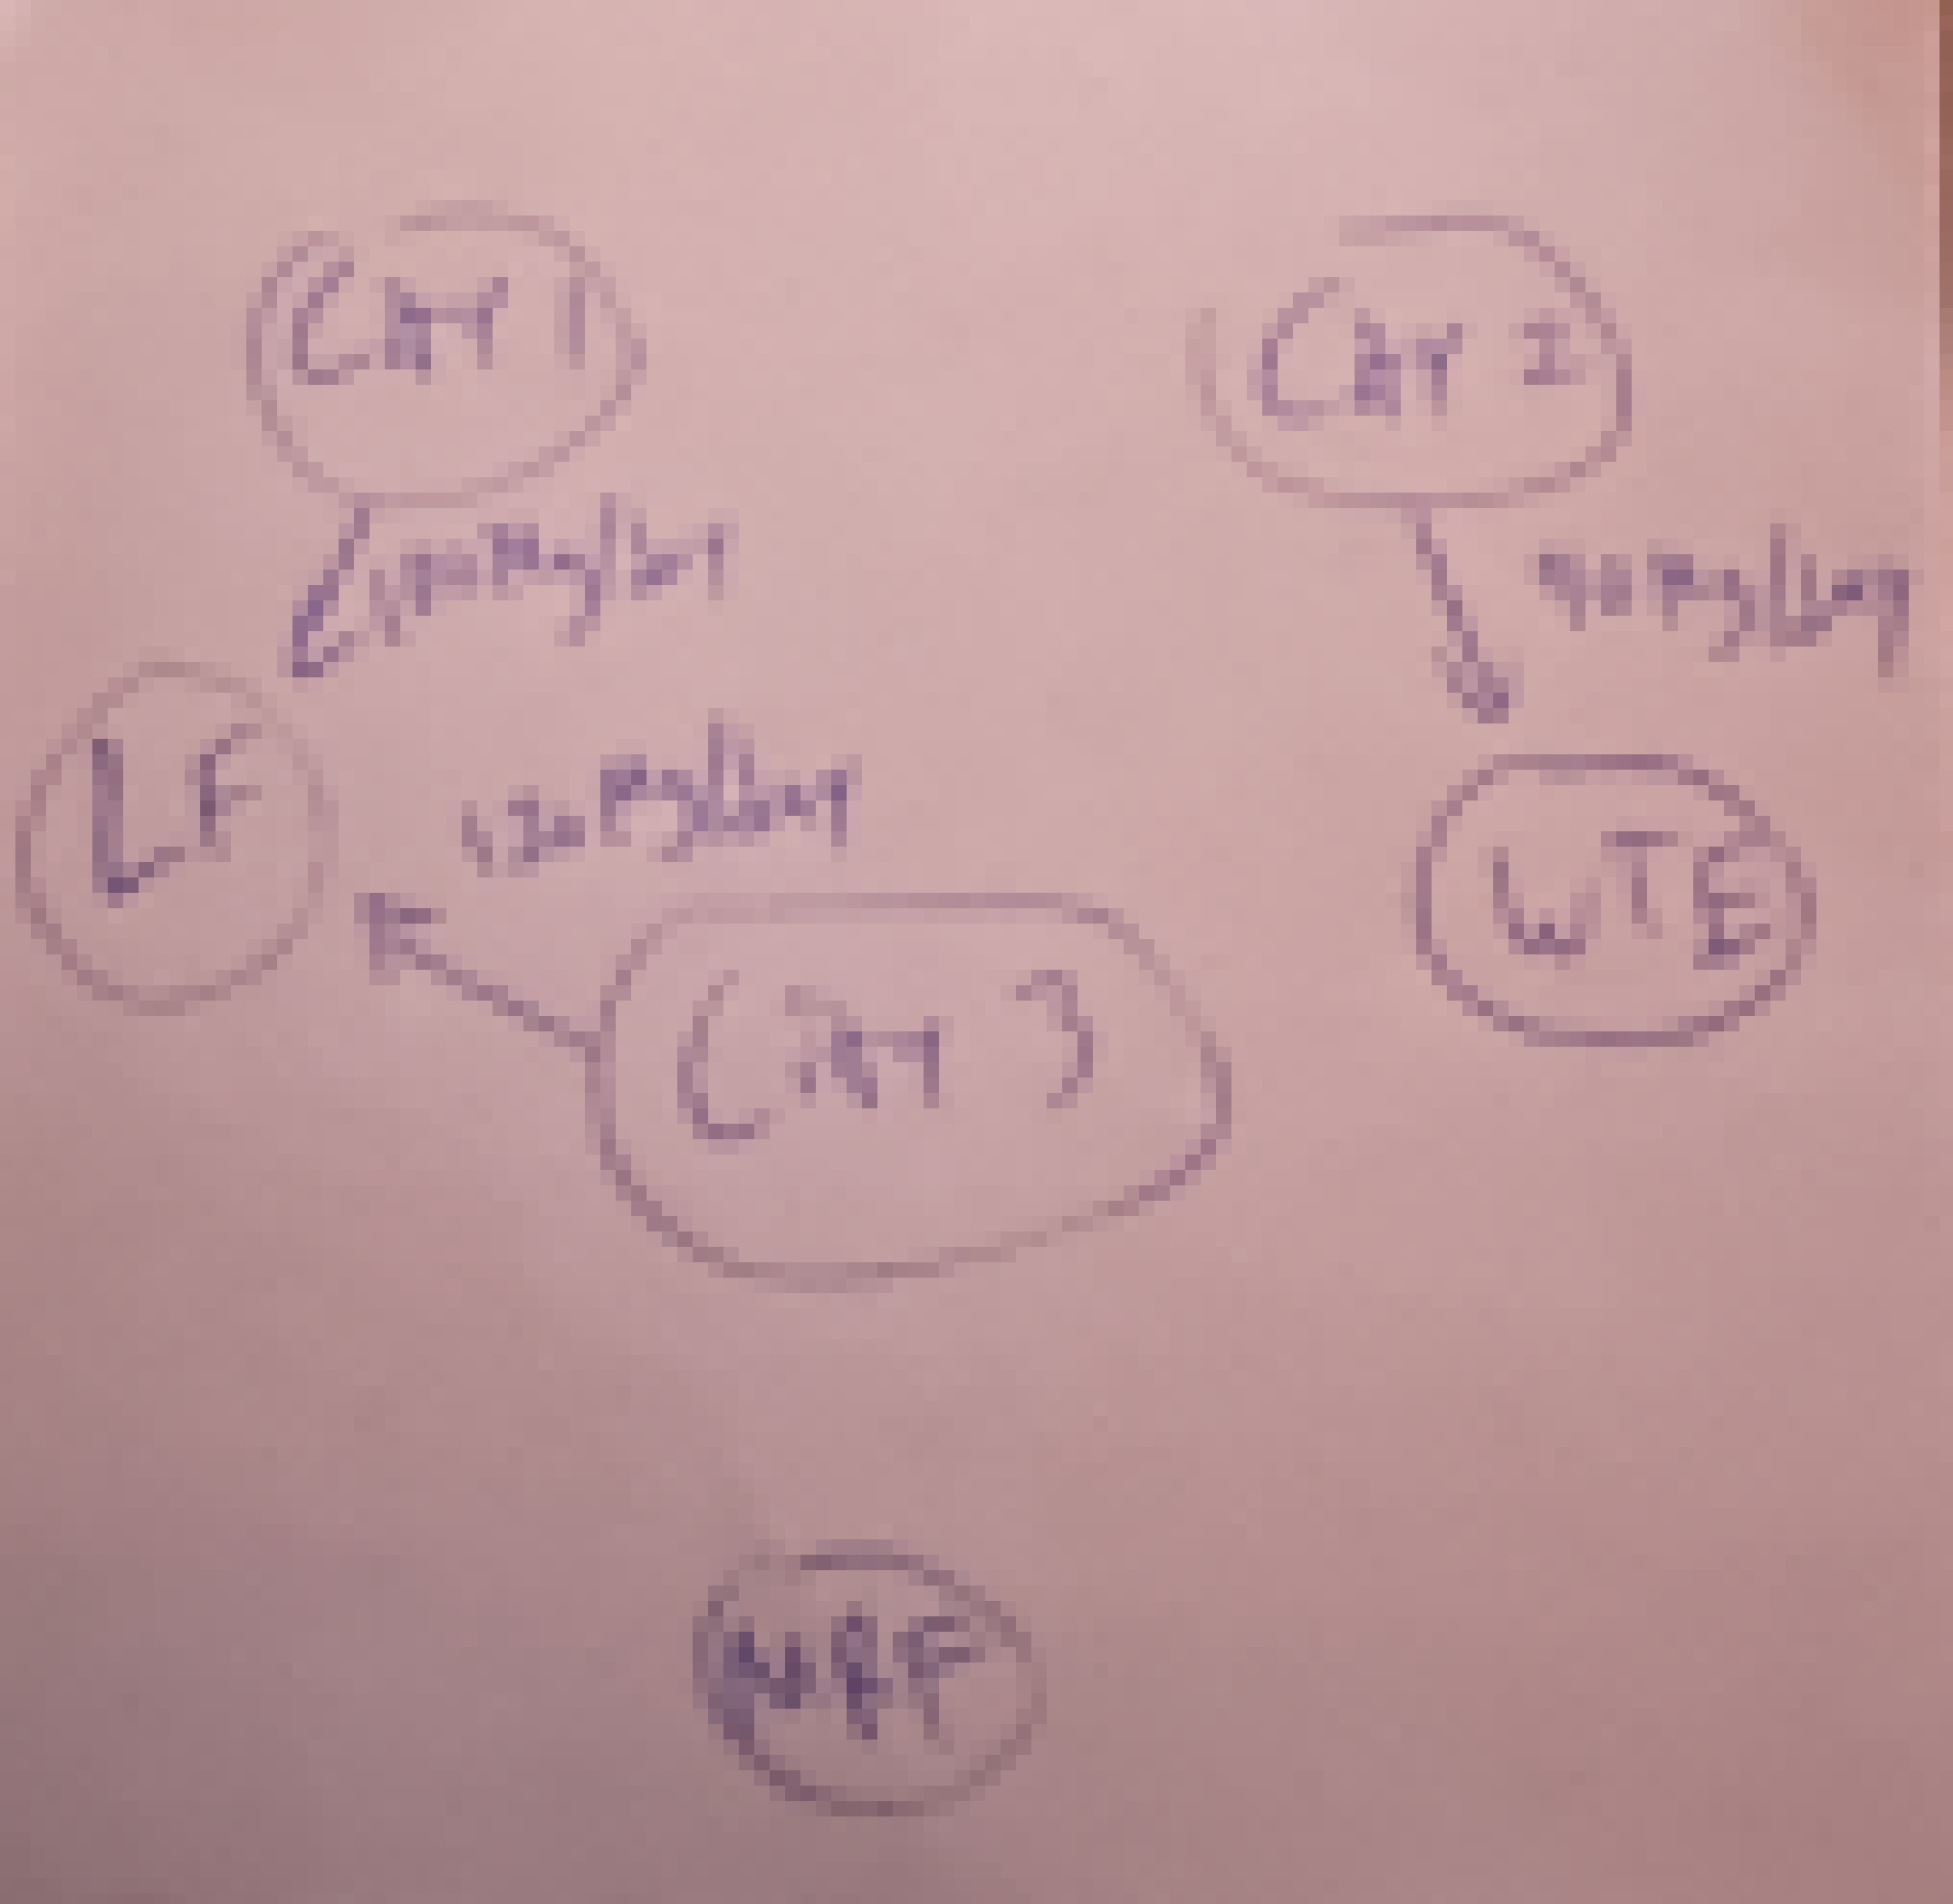

┌ Warning: Output swatches are reduced due to the large size (1979×2030).
│ Load the ImageShow package for large images.
└ @ Colors /Users/user/.julia/packages/Colors/VFEJ1/src/display.jl:159


In [40]:
img = load("IMG_4272_2.jpg")
display(img)

--> Code Explanation: I used external packages to load a Jpeg image into this file, however it has very low quality.

--> Figure Explanation: City 1 and 3 send all of their waste to the Landfill, while City 2 send sall of its to the WTE, none goes to the MRF, potentially because it is too far away to be economically viable from any of the cities.

### Problem 2 (6 points)

Consider a two-period economic dispatch problem, based on the
multi-period example from Lecture 14 (on 10/29). The generator data,
including ramping constraints for each generator, is provided in
\`data/generators.csv.’ In period 1, the demand is
$d_1 = 1100 \text{MW}$. In period 2, the demand is projected to be
$d_2 = 1200 \text{MW}$, but there is a 25% probability that it is \$1500
. In the first period, the solar capacity factor is $0.9$ and the wind
capacity factor is $0.45$, but in the second period, there is some
uncertainty: the forecasted solar and wind capacity factors are $0.95$
and $0.4$, respectively, but there is a 30% probability that they are
$0.75$ and $0.5$. Your goal is to identify how to dispatch your
generators to minimize the cost of meeting demand.

#### Problem 2.1

Draw a scenario tree for this problem.

--> Since the previous image had too low of a resolution to tell what the image was depicting, I wil describe the scenario tree:

--> This problem has two periods. Period 1 is deterministic, so the scenario tree begins with a single root node with known demand and known renewable capacity factors. Uncertainty occurs only in Period 2. There are two independent sources of uncertainty:

**Demand uncertainty:**
- With probability 0.75, Period-2 demand equals the forecasted value.
- With probability 0.25, Period-2 demand is 1500.

--> Renewable capacity uncertainty (solar and wind):
- With probability 0.70, solar and wind use their forecasted capacity factors.
- With probability 0.30, they take lower alternative capacity factors.

Combining these independent uncertainties produces four Period-2 scenarios:

Scenario A: forecast demand + forecast renewables  

- Probability = 0.75 × 0.70 = 0.525

Scenario B: forecast demand + alternative renewables  

- Probability = 0.75 × 0.30 = 0.225

Scenario C: high demand (1500) + forecast renewables  

- Probability = 0.25 × 0.70 = 0.175

Scenario D: high demand (1500) + alternative renewables  

- Probability = 0.25 × 0.30 = 0.075

--> Therefore, the scenario tree has one deterministic node in Period 1 and four possible leaf scenarios in Period 2.

#### Problem 2.2

Formulate a stochastic linear program for this problem based on your
scenario tree from Problem 2.1 and the data in `data/generators.csv`.

**Objective**

- $\min\;\sum_{g\in G} \text{cost}[g]\;P[g,1]\;+\;\sum_{s\in S} p[s]\;\sum_{g\in G} \text{cost}[g]\;P[g,s]$

--> Capacity bounds

- $\text{Pmin}[g]\;\le\;P[g,1]\;\le\;\text{Pmax}[g]\quad\forall g$

- $\text{Pmin}[g]\;\le\;P[g,s]\;\le\;\text{Pmax}[g]\quad\forall g,\;s$

--> Power balance

- $\sum_{g\in G} P[g,1] + \text{R1\_solar} + \text{R1\_wind} = \text{D1}$

- $\sum_{g\in G} P[g,s] + \text{R2\_solar}[s] + \text{R2\_wind}[s] = \text{D2}[s]\quad\forall s$

--> Ramping constraints

- $P[g,s] - P[g,1] \le \text{ramp\_up}[g]\quad\forall g,\;s$

- $P[g,1] - P[g,s] \le \text{ramp\_down}[g]\quad\forall g,\;s$

--> Nonnegativity

- $P[g,1] \ge 0$

- $P[g,s] \ge 0\quad\forall g,\;s$

## References

List any external references consulted, including classmates.

--> Worked alone, no references besides Julia syntax pages online.